In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import kpss
from statsmodels.tools.eval_measures import rmse
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose



Samples: 846
                  FEDFUNDS
observation_date          
1954-07-01            0.80
1954-08-01            1.22
1954-09-01            1.07
1954-10-01            0.85
1954-11-01            0.83
ADF Statistic: -2.9711206713515335
P-value: 0.03768080353819331
Critical Values: {'1%': np.float64(-3.438272329479064), '5%': np.float64(-2.8650369467745573), '10%': np.float64(-2.568632068251301)}
Reject H0: Data is stationary
KPSS Statistic: 1.2556275391699085
P-value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0: Data is non-stationary


/var/folders/b9/z9wybbyd3ydcghf9x081bk0c0000gn/T/ipykernel_42392/3281385527.py:34: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_test = kpss(series, regression=regression)
/opt/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/var/folders/b

                               SARIMAX Results                                
Dep. Variable:               FEDFUNDS   No. Observations:                  846
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -508.057
Date:                Mon, 10 Feb 2025   AIC                           1024.113
Time:                        17:13:42   BIC                           1043.070
Sample:                    07-01-1954   HQIC                          1031.377
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
observation_date     0.0045      0.026      0.178      0.859      -0.045       0.055
ar.L1                0.1032      0.036      2.877      0.004       0.033       0.173
ma.L1                0.3442 

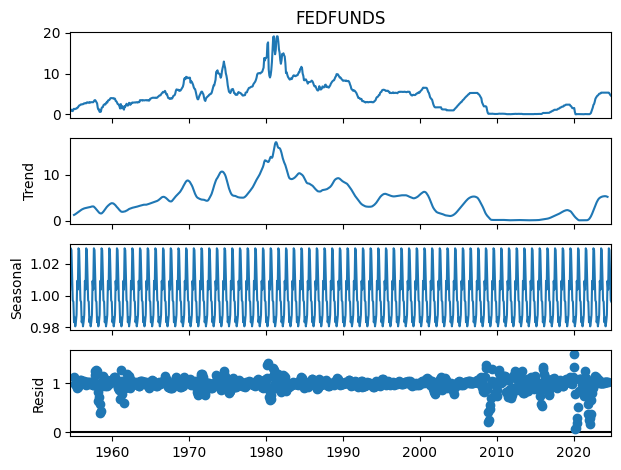

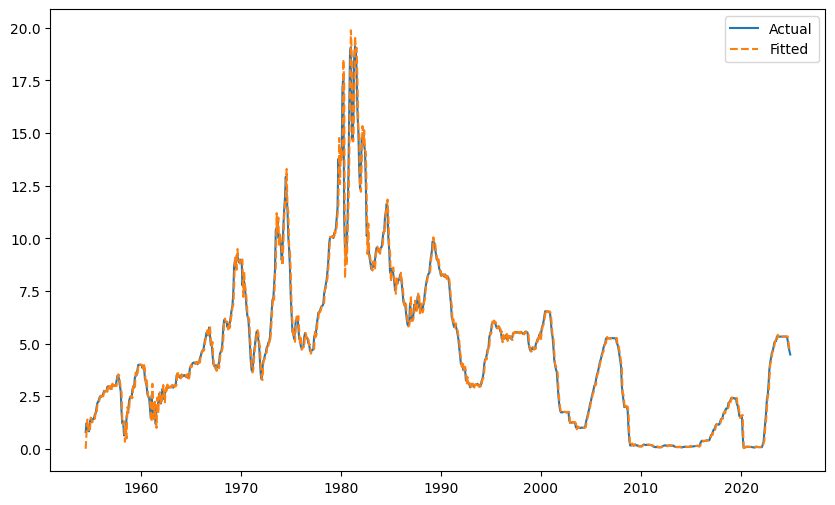

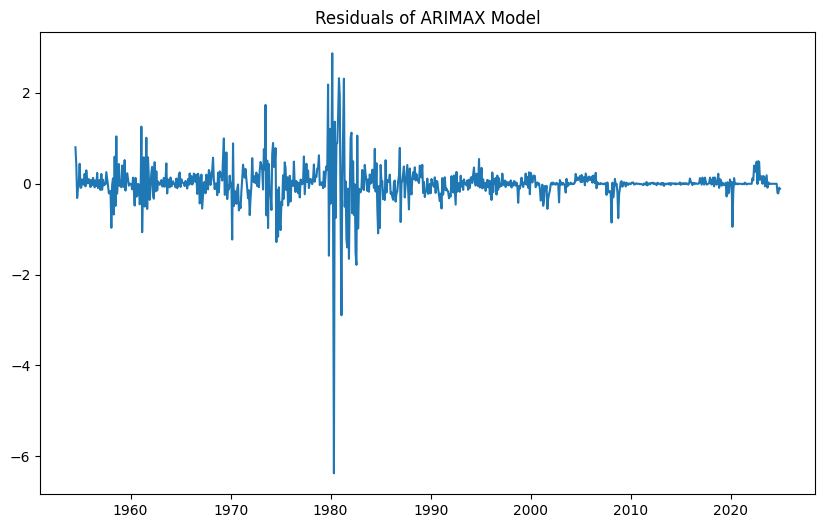

Forecasted Values: 2025-01-01    4.428458
2025-02-01    4.427217
2025-03-01    4.431164
2025-04-01    4.435647
2025-05-01    4.440186
                ...   
2049-08-01    5.762681
2049-09-01    5.767226
2049-10-01    5.771771
2049-11-01    5.776315
2049-12-01    5.780860
Freq: MS, Name: predicted_mean, Length: 300, dtype: float64


/var/folders/b9/z9wybbyd3ydcghf9x081bk0c0000gn/T/ipykernel_42392/3281385527.py:88: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=data.index[-1], periods=forecast_steps + 1, freq='M')[1:]


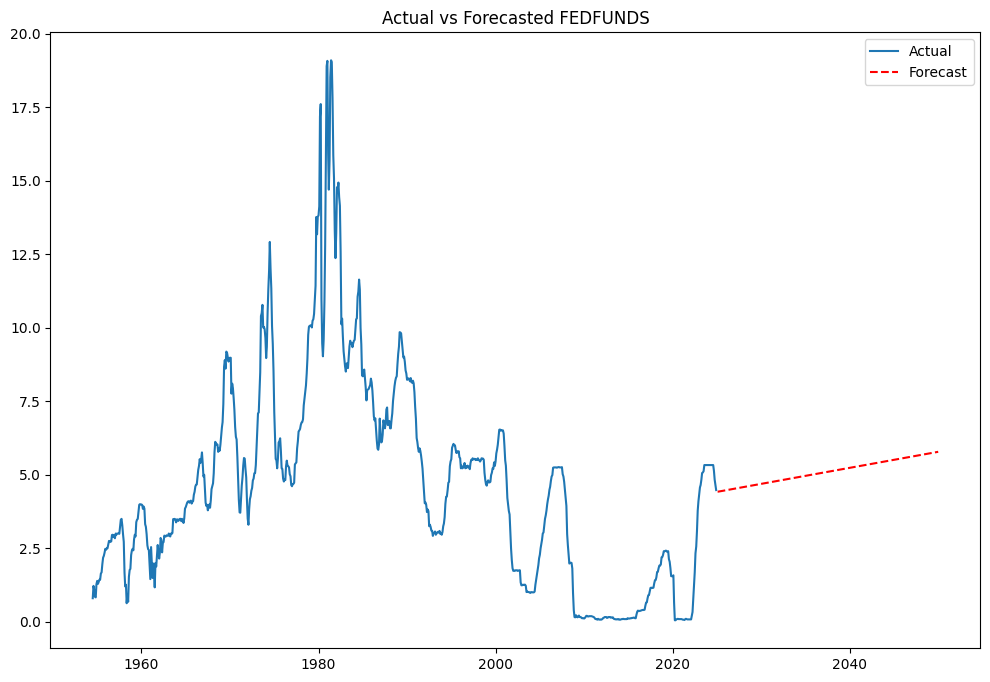

In [ ]:
data = pd.read_csv('/Users/alexren/Demand-Forecast/dataset/FEDFUNDS.csv', 
                       parse_dates=['observation_date'], index_col='observation_date')

print("Samples:", len(data))

print(data.head())


# Graph
result = seasonal_decompose(data['FEDFUNDS'],  
                            model ='multiplicative')

result.plot()

# data["detrended"] = sm.OLS(data["FEDFUNDS"], sm.add_constant(range(len(data)))).fit().resid
# data["differenced"] = data["FEDFUNDS"].diff()


# ADF Test
result_test = adfuller(data)

print(f"ADF Statistic: {result_test[0]}")
print(f"P-value: {result_test[1]}")
print(f"Critical Values: {result_test[4]}")

if result_test[1] < 0.05:
    print("Reject H0: Data is stationary")
else:
    print("Fail to reject H0: Data is non-stationary")


# KPSS Test
def kpss_test(series, regression='c'):
    result_test = kpss(series, regression=regression)
    p_value = result_test[1]
    print(f"KPSS Statistic: {result_test[0]}")
    print(f"P-value: {result_test[1]}")
    print(f"Critical Values: {result_test[3]}")
    
    if p_value < 0.05:
        print("Reject H0: Data is non-stationary")
    else:
        print("Fail to Reject H0: Data is stationary")

kpss_test(data['FEDFUNDS'])

# Stationary / Non-Stationary???

# ARIMAX Model Adjustments
data['observation_date'] = np.arange(len(data))
x = data[['observation_date']]

arimax_model = ARIMA(data['FEDFUNDS'], exog = x, order=(1, 1, 1))
arimax_fit = arimax_model.fit()

print(arimax_fit.summary())

# Check Residuals
residuals = arimax_fit.resid
kpss_test(residuals)


# Plotting the Results
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['FEDFUNDS'], label='Actual')
plt.plot(data.index, arimax_fit.fittedvalues, label='Fitted', linestyle='--')
plt.legend()
plt.show()

# Plotting the Residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title('Residuals of ARIMAX Model')
plt.show()


# Forecasting
forecast_steps = 300
future_time = np.arange(len(data), len(data) + forecast_steps)
future_exog = pd.DataFrame(future_time, columns=['observation_date'])

forecast_values = arimax_fit.forecast(steps=forecast_steps, exog=future_exog)

print("Forecasted Values:", forecast_values)

# Plot Forecast

forecast_dates = pd.date_range(start=data.index[-1], periods=forecast_steps + 1, freq='M')[1:]

plt.figure(figsize=(12, 8))
plt.plot(data.index, data['FEDFUNDS'], label='Actual')
plt.plot(forecast_dates, forecast_values, label='Forecast', linestyle='--', color='red')
plt.legend()
plt.title('Actual vs Forecasted FEDFUNDS')
plt.show()